<a href="https://colab.research.google.com/github/srilakshmi-saladi/unet/blob/main/custom_brain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Device: cpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
split  label_name
test   glioma         254
       meningioma     306
       no_tumor       140
       pituitary      300
train  glioma        1147
       meningioma    1329
       no_tumor      1067
       pituitary     1457
dtype: int64
No validation folder found! Splitting 15% of train data for validation...
Loaders ready.


Ep 01/20 | train loss=1.1027 acc=0.5218 | val loss=0.8353 acc=0.6307 f1=0.6093 qwk=0.6116


Ep 02/20 | train loss=0.9425 acc=0.6113 | val loss=1.1170 acc=0.5133 f1=0.4487 qwk=0.4113


Ep 03/20 | train loss=0.8957 acc=0.6243 | val loss=0.6054 acc=0.7773 f1=0.7828 qwk=0.7065


Ep 04/20 | train loss=0.8626 acc=0.6283 | val loss=0.7090 acc=0.7293 f1=0.7310 qwk=0.7460


...

Ep 19/20 | train loss=0.7097 acc=0.7060 | val loss=0.4167 acc=0.8560 f1=0.8614 qwk=0.8265


Ep 20/20 | train loss=0.7009 acc=0.7254 | val loss=0.4269 acc=0.8507 f1=0.8568 qwk=0.8132


,epoch,train_loss,train_acc,val_loss,val_acc,val_f1,val_qwk
15,16,0.721240,0.717566,0.443904,0.845333,0.853462,0.803604
16,17,0.728937,0.723248,0.442512,0.829333,0.834640,0.806564
17,18,0.734436,0.705492,0.440313,0.828000,0.832215,0.796822
18,19,0.709729,0.705966,0.416747,0.856000,0.861402,0.826501
19,20,0.700893,0.725379,0.426877,0.850667,0.856788,0.813192


TTA: 100%|██████████| 125/125 [01:20<00:00,  1.56it/s]


Accuracy: 0.785
Macro F1: 0.79159233655746
QWK: 0.800597897157979
              precision    recall  f1-score   support

      glioma       0.89      0.71      0.79       254
  meningioma       0.67      0.69      0.68       306
    no_tumor       0.72      0.99      0.83       140
   pituitary       0.89      0.85      0.87       300

    accuracy                           0.79      1000
   macro avg       0.79      0.81      0.79      1000
weighted avg       0.80      0.79      0.79      1000



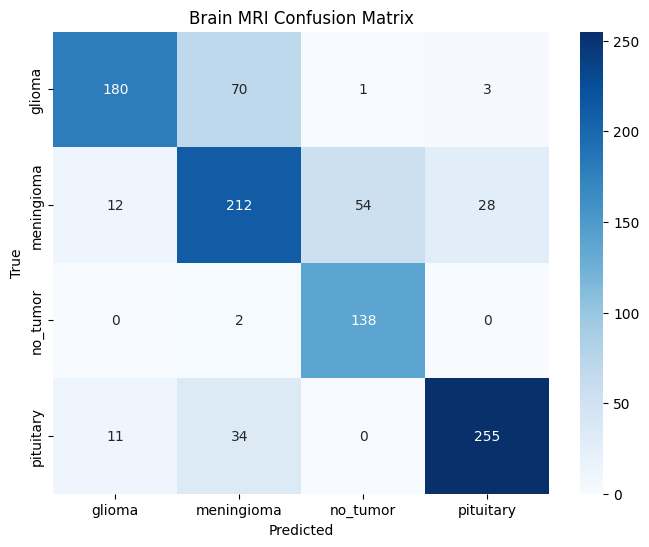

In [4]:
import os, random, warnings, copy
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, cohen_kappa_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms as T

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = Path('/content/drive/MyDrive/brain dataset/brisc2025/classification_task')  # change this
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20
LR = 3e-4
USE_TTA = True

def image_files_in(folder):
    return [p for p in folder.rglob('*') if p.suffix.lower() in ['.png', '.jpg', '.jpeg']]

train_dir = BASE_DIR / 'train'
val_dir = BASE_DIR / 'val'
test_dir = BASE_DIR / 'test'
records = []

if train_dir.exists() and test_dir.exists():
    class_names = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
    class2idx = {c:i for i,c in enumerate(class_names)}
    for split_name, split_dir in [('train', train_dir), ('val', val_dir), ('test', test_dir)]:
        if split_dir.exists():
            for cls in class_names:
                for p in image_files_in(split_dir / cls):
                    records.append({'path': str(p), 'label_name': cls, 'label': class2idx[cls], 'split': split_name})
    df = pd.DataFrame(records)
else:
    class_names = sorted([d.name for d in BASE_DIR.iterdir() if d.is_dir()])
    class2idx = {c:i for i,c in enumerate(class_names)}
    for cls in class_names:
        for p in image_files_in(BASE_DIR / cls):
            records.append({'path': str(p), 'label_name': cls, 'label': class2idx[cls]})
    df = pd.DataFrame(records)
    train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=SEED)
    val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED)
    train_df['split'] = 'train'
    val_df['split'] = 'val'
    test_df['split'] = 'test'
    df = pd.concat([train_df, val_df, test_df], ignore_index=True)

print("Classes:", class_names)
print(df.groupby(['split','label_name']).size())

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

def get_transforms(img_size, mode='train'):
    if mode == 'train':
        return T.Compose([
            T.Resize((img_size + 16, img_size + 16)),
            T.RandomCrop(img_size),
            T.RandomHorizontalFlip(),
            T.RandomRotation(10),
            T.ColorJitter(brightness=0.08, contrast=0.08),
            T.ToTensor(),
            T.Normalize(MEAN, STD),
        ])
    return T.Compose([
        T.Resize((img_size, img_size)),
        T.ToTensor(),
        T.Normalize(MEAN, STD),
    ])

class ImageClsDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        y = int(row['label'])
        if self.transform: img = self.transform(img)
        return img, y

train_df = df[df['split']=='train'].reset_index(drop=True)
val_df = df[df['split']=='val'].reset_index(drop=True)
test_df = df[df['split']=='test'].reset_index(drop=True)
if len(val_df) == 0:
    print("No validation folder found! Splitting 15% of train data for validation...")
    from sklearn.model_selection import train_test_split
    train_df, val_df = train_test_split(train_df, test_size=0.15, stratify=train_df['label'], random_state=SEED)
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)

counts = train_df['label'].value_counts().sort_index().values.astype(float)
class_weights = (1.0 / counts)
class_weights = class_weights / class_weights.sum() * len(class_names)
CLASS_WEIGHTS_TENSOR = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

# --- OPTIMIZED DATA LOADERS ---
NUM_WORKERS = 2
train_loader = DataLoader(ImageClsDataset(train_df, get_transforms(IMG_SIZE, 'train')), batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2)
val_loader = DataLoader(ImageClsDataset(val_df, get_transforms(IMG_SIZE, 'val')), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2)
test_loader = DataLoader(ImageClsDataset(test_df, get_transforms(IMG_SIZE, 'val')), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2)
print("Loaders ready.")

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, 3, stride=stride, padding=1, groups=in_ch, bias=False)
        self.pw = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU(inplace=True)
    def forward(self, x):
        x = self.dw(x)
        x = self.pw(x)
        x = self.bn(x)
        return self.act(x)

class BrainSECNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )
        self.block1 = nn.Sequential(DepthwiseSeparableConv(32, 64, stride=2), SEBlock(64))
        self.block2 = nn.Sequential(DepthwiseSeparableConv(64, 128, stride=2), SEBlock(128))
        self.block3 = nn.Sequential(DepthwiseSeparableConv(128, 256, stride=2), SEBlock(256))
        self.block4 = nn.Sequential(DepthwiseSeparableConv(256, 512, stride=2), SEBlock(512))
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.35),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.head(x)
        return x

def mixup_data(x, y, alpha=0.3):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0)).to(x.device)
    return lam*x + (1-lam)*x[idx], y, y[idx], lam

def mixup_loss(criterion, out, ya, yb, lam):
    return lam * criterion(out.float(), ya) + (1-lam) * criterion(out.float(), yb)

def train_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, leave=False, desc='Train'):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with autocast():
            if random.random() < 0.5:
                imgs, ya, yb, lam = mixup_data(imgs, labels)
                out = model(imgs)
                loss = mixup_loss(criterion, out, ya, yb, lam)
            else:
                out = model(imgs)
                loss = criterion(out.float(), labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss/total, correct/total

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    criterion_eval = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS_TENSOR)
    total_loss, all_preds, all_labels = 0.0, [], []
    total = 0
    for imgs, labels in tqdm(loader, leave=False, desc='Eval'):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with autocast():
            out = model(imgs)
        loss = criterion_eval(out.float(), labels)
        probs = F.softmax(out, dim=1)
        total_loss += loss.item() * imgs.size(0)
        all_preds.extend(probs.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        total += imgs.size(0)

    # Handle empty loader case to prevent ZeroDivisionError
    if total == 0:
        return 0.0, 0.0, 0.0, np.nan, np.array([]), np.array([])

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    return total_loss/total, acc, f1, qwk, np.array(all_preds), np.array(all_labels)

# --- OPTIMIZED MODEL SETUP ---
torch.backends.cudnn.benchmark = True
model = BrainSECNN(len(class_names)).to(DEVICE)

if torch.__version__ >= "2.0.0":
    import torch._dynamo
    torch._dynamo.config.suppress_errors = True
    model = torch.compile(model)

criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS_TENSOR, label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)
scaler = GradScaler()

best_f1, best_state = -1, None
history = []

for ep in range(1, EPOCHS+1):
    tl, ta = train_epoch(model, train_loader, optimizer, criterion, scaler)
    vl, va, vf1, vqwk, _, _ = evaluate(model, val_loader)
    scheduler.step()
    history.append([ep, tl, ta, vl, va, vf1, vqwk])
    print(f"Ep {ep:02d}/{EPOCHS} | train loss={tl:.4f} acc={ta:.4f} | val loss={vl:.4f} acc={va:.4f} f1={vf1:.4f} qwk={vqwk:.4f}")
    if vf1 > best_f1:
        best_f1 = vf1
        best_state = copy.deepcopy(model.state_dict())

model.load_state_dict(best_state)
torch.save(model.state_dict(), '/content/brain_secnn_best.pth')
display(pd.DataFrame(history, columns=['epoch','train_loss','train_acc','val_loss','val_acc','val_f1','val_qwk']).tail())

tta_transforms = [
    T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor(), T.Normalize(MEAN, STD)]),
    T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.RandomHorizontalFlip(p=1), T.ToTensor(), T.Normalize(MEAN, STD)]),
]

class TTADataset(Dataset):
    def __init__(self, df, transforms_list):
        self.df = df.reset_index(drop=True)
        self.transforms_list = transforms_list
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        label = int(row['label'])
        imgs = [tr(img) for tr in self.transforms_list]
        return imgs, label

tta_dataset = TTADataset(test_df, tta_transforms)

@torch.no_grad()
def evaluate_tta(model, tta_dataset, batch_size=8):
    model.eval()
    all_probs, all_labels = [], []
    for start in tqdm(range(0, len(tta_dataset), batch_size), desc='TTA'):
        batch_items = [tta_dataset[i] for i in range(start, min(start+batch_size, len(tta_dataset)))]
        labels = torch.tensor([x[1] for x in batch_items]).to(DEVICE)
        probs_sum = None
        for t_idx in range(len(tta_transforms)):
            imgs = torch.stack([x[0][t_idx] for x in batch_items]).to(DEVICE)
            with autocast():
                out = model(imgs)
                probs = F.softmax(out, dim=1)
            probs_sum = probs if probs_sum is None else probs_sum + probs
        probs_avg = probs_sum / len(tta_transforms)
        all_probs.extend(probs_avg.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    preds = np.argmax(all_probs, axis=1)
    acc = accuracy_score(all_labels, preds)
    f1 = f1_score(all_labels, preds, average='macro', zero_division=0)
    qwk = cohen_kappa_score(all_labels, preds, weights='quadratic')
    return acc, f1, qwk, preds, all_labels

if USE_TTA:
    acc, f1, qwk, preds, labels = evaluate_tta(model, tta_dataset, batch_size=8)
else:
    _, acc, f1, qwk, preds, labels = evaluate(model, test_loader)

print("Accuracy:", acc)
print("Macro F1:", f1)
print("QWK:", qwk)
print(classification_report(labels, preds, target_names=class_names))

cm = confusion_matrix(labels, preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Brain MRI Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()